In [2]:
%load_ext autoreload
%autoreload 2


import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))


In [3]:
from statistics import mean
import pandas as pd

from scripts.main import load_graph_and_communities


datasets = [
    'Algebra',
    'Geometry',
    'Restaurants-Rev',
    'Music-Rev',
    'Bars-Rev',
    'contact-primary-school'
]

rows = []

for dataset in datasets:
    graph, comm = load_graph_and_communities(dataset, tau=None, verbose=False, source=False)

    # Basic counts
    n_nodes = len(graph.nodes)
    n_hyperedges = len(graph.hyperedges)

    # Hyperedge sizes
    hyperedge_sizes = [len(hedge_nodes) for hedge_nodes in graph.hyperedges.values()]
    avg_hyperedge_size = mean(hyperedge_sizes) if hyperedge_sizes else 0
    max_hyperedge_size = max(hyperedge_sizes) if hyperedge_sizes else 0

    # Projected node degree + node hyperdegree
    neighbors = {node: set() for node in graph.nodes}
    node_hyperdegrees = {node: 0 for node in graph.nodes}

    for hedge_nodes in graph.hyperedges.values():
        for node in hedge_nodes:
            neighbors[node].update(hedge_nodes - {node})
            node_hyperdegrees[node] += 1

    degree_values = [len(neighbors[node]) for node in graph.nodes]
    hyperdegree_values = list(node_hyperdegrees.values())

    avg_node_degree = mean(degree_values) if degree_values else 0
    max_node_degree = max(degree_values) if degree_values else 0
    avg_node_hyperdegree = mean(hyperdegree_values) if hyperdegree_values else 0
    max_node_hyperdegree = max(hyperdegree_values) if hyperdegree_values else 0

    rows.append({
        "Dataset": dataset,
        "Nodes": n_nodes,
        "Hyperedges": n_hyperedges,
        "Avg. hyperedge size": round(avg_hyperedge_size, 2),
        "Max. hyperedge size": max_hyperedge_size,
        "Avg. node degree": round(avg_node_degree, 2),
        "Max. node degree": max_node_degree,
        "Avg. hyperdegree": round(avg_node_hyperdegree, 2),
    })

summary_df = pd.DataFrame(rows)

# Save for Overleaf / Excel / manual table copy
summary_df.to_csv("dataset_summary.csv", index=False)

summary_df

,Dataset,Nodes,Hyperedges,Avg. hyperedge size,Max. hyperedge size,Avg. node degree,Max. node degree,Avg. hyperdegree
0,Algebra,423,1268,6.52,107,78.90,303,19.53
1,Geometry,580,1193,10.47,230,164.79,474,21.53
2,Restaurants-Rev,565,601,7.66,43,79.75,310,8.14
3,Music-Rev,1106,694,15.13,83,167.88,865,9.49
4,Bars-Rev,1234,1194,9.94,73,174.30,818,9.62
5,contact-primary-school,242,12704,2.42,5,68.74,134,126.98


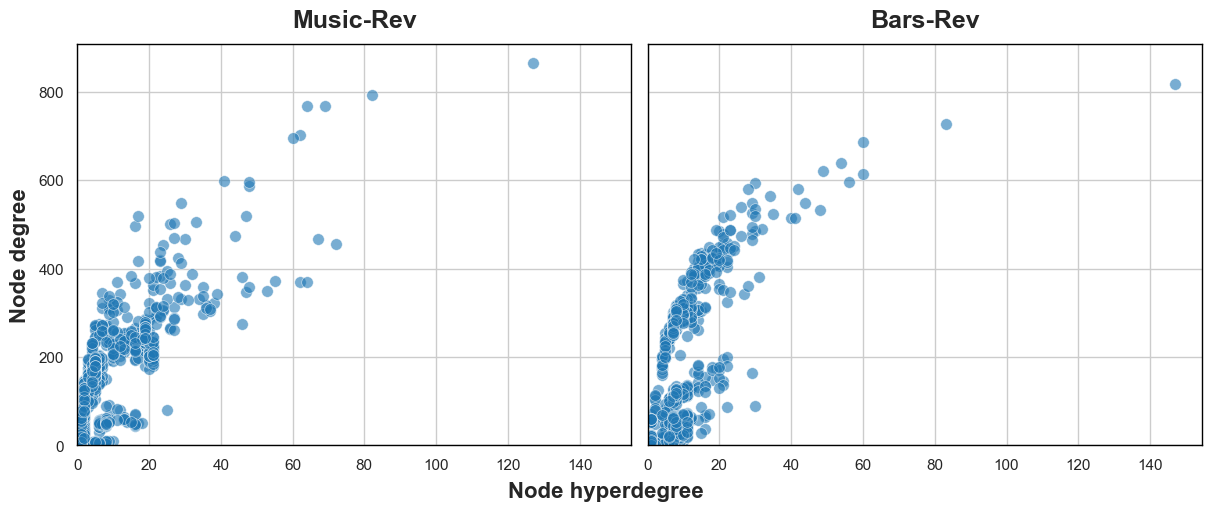

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming this import works in your environment
from scripts.main import load_graph_and_communities

datasets = [
    'Music-Rev',
    'Bars-Rev'
]

# ==========================================
# 1. Data Extraction (Node-level)
# ==========================================
node_data = []

for dataset in datasets:
    graph, comm = load_graph_and_communities(dataset, tau=None, verbose=False, source=False)

    neighbors = {node: set() for node in graph.nodes}
    node_hyperdegrees = {node: 0 for node in graph.nodes}

    for hedge_nodes in graph.hyperedges.values():
        for node in hedge_nodes:
            neighbors[node].update(hedge_nodes - {node})
            node_hyperdegrees[node] += 1

    for node in graph.nodes:
        node_data.append({
            "Dataset": dataset,
            "Node": node,
            "Degree": len(neighbors[node]),
            "Hyperdegree": node_hyperdegrees[node]
        })

df_nodes = pd.DataFrame(node_data)

# ==========================================
# 2. Visualization: Professional Shared Axes Scatterplot
# ==========================================
# Use a clean theme with explicit black bounding boxes for a professional look
sns.set_theme(style="whitegrid", rc={"axes.edgecolor": "black", "axes.linewidth": 1})
plt.rcParams.update({"font.size": 14})

# constrained_layout is superior to tight_layout when using fig.supxlabel/ylabel
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True, constrained_layout=True)

for i, dataset in enumerate(datasets):
    ax = axes[i]
    dataset_df = df_nodes[df_nodes["Dataset"] == dataset]
    
    # Scatter points with refined aesthetics
    sns.scatterplot(
        data=dataset_df, 
        x="Hyperdegree", 
        y="Degree", 
        color="#1f77b4", 
        alpha=0.6,          # Slightly less transparent for a crisper finish
        edgecolor="white", 
        linewidth=0.5,      # Thinner white edge for polish
        s=70, 
        ax=ax
    )
    
    # Subplot formatting
    ax.set_title(dataset, weight='bold', size=18, pad=12)
    ax.set_xlabel("")
    ax.set_ylabel("")
    
    # Lock the grid and axes exactly to the origin (0, 0)
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)

# Apply global upper limits with a 5% margin so top/right points aren't cut off
global_max_x = df_nodes["Hyperdegree"].max()
global_max_y = df_nodes["Degree"].max()
axes[0].set_xlim(right=global_max_x * 1.05)
axes[0].set_ylim(top=global_max_y * 1.05)

# Add shared global axis labels
fig.supxlabel("Node hyperdegree", weight='bold', fontsize=16)
fig.supylabel("Node degree", weight='bold', fontsize=16)

plt.show()

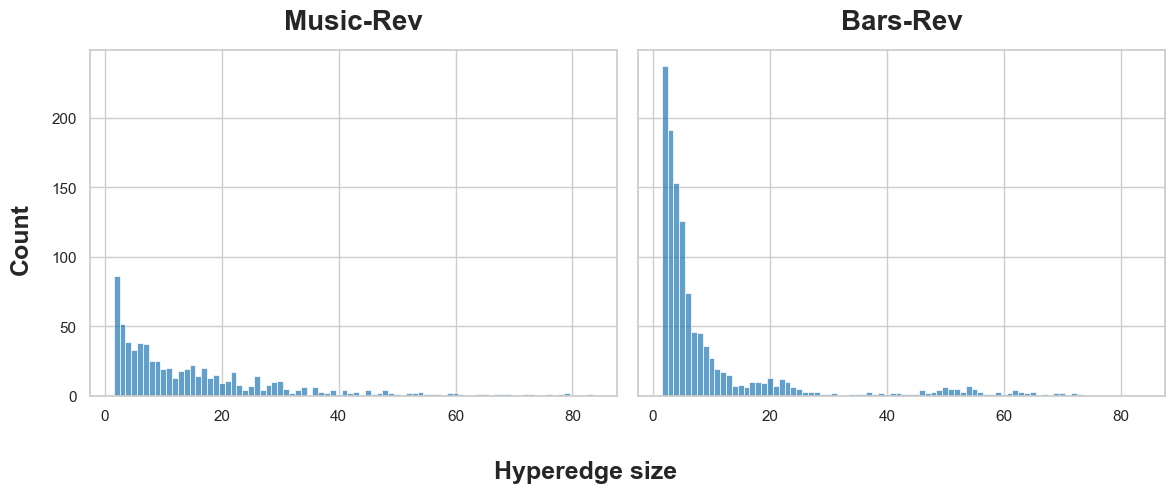

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming this import works in your environment
from scripts.main import load_graph_and_communities

datasets = [
    'Music-Rev',
    'Bars-Rev'
]

# ==========================================
# 1. Data Extraction (Hyperedge-level)
# ==========================================
hedge_data = []

for dataset in datasets:
    graph, comm = load_graph_and_communities(dataset, tau=None, verbose=False, source=False)

    # Extract the size of every single hyperedge in the dataset
    for hedge_id, hedge_nodes in graph.hyperedges.items():
        hedge_data.append({
            "Dataset": dataset,
            "Hyperedge Size": len(hedge_nodes)
        })

df_hedges = pd.DataFrame(hedge_data)

# ==========================================
# 2. Visualization: Shared Axes Histogram
# ==========================================
sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.size": 14})

# Lock scales together for a perfect 1-to-1 visual comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

for i, dataset in enumerate(datasets):
    ax = axes[i]
    dataset_df = df_hedges[df_hedges["Dataset"] == dataset]
    
    # Histogram with discrete=True since group sizes are exact integers
    sns.histplot(
        data=dataset_df, 
        x="Hyperedge Size", 
        color="#1f77b4", 
        alpha=0.7, 
        edgecolor="white",
        linewidth=0.5,
        discrete=True, 
        ax=ax
    )
    
    # Subplot titles
    ax.set_title(dataset, weight='bold', size=20, pad=15)
    
    # Clear individual subplot axis labels
    ax.set_xlabel("")
    ax.set_ylabel("")

# Global shared axis labels
fig.supxlabel("Hyperedge size", weight='bold', fontsize=18)
fig.supylabel("Count", weight='bold', fontsize=18)

plt.tight_layout()
plt.show()